# Mass ordering and the $\theta_{23}$ octant

Two things about the neutrino mass spectrum are still unmeasured, and both show up in
oscillation probabilities:

* **The ordering.** Is $\nu_3$ the heaviest state (normal ordering, NO) or the lightest
  (inverted, IO)? In Mag$\nu$s this is carried entirely by the **sign of `D31`**
  ($\Delta m^2_{31}$) -- positive for NO, negative for IO. Nothing else changes.
* **The octant.** Is $\theta_{23}$ below $45^\circ$ or above it? Disappearance experiments
  measure something close to $\sin^2 2\theta_{23}$, which cannot tell $\theta_{23}$ from
  $90^\circ - \theta_{23}$.

A warning about the shipped parameter sets before we start.
`gd.load_nufit_params('NuFIT 6.1', 'NO')` and `(..., 'IO')` are the NuFIT 6.1 best fits for each
ordering, and they differ in **both** things at once -- and in $\delta_{\rm CP}$ as well. Using
them as an ordering comparison conflates three effects. To isolate one variable we flip the
sign of `D31` by hand and change nothing else.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

NO = gd.load_nufit_params('NuFIT 6.1', 'NO')
IO_fit = gd.load_nufit_params('NuFIT 6.1', 'IO')
KEYS = tuple(NO)

print('%-6s %-14s %-14s' % ('', 'NuFIT NO', 'NuFIT IO'))
for k in KEYS:
    print('%-6s %+.6e %+.6e' % (k, NO[k], IO_fit[k]))
print()
print('sin^2(th23): %.3f vs %.3f  <- different octants, too'
      % (NO['s23']**2, IO_fit['s23']**2))

       NuFIT NO       NuFIT IO      
s12    +5.556978e-01 +5.556978e-01
s23    +6.855655e-01 +7.416198e-01
s13    +1.499333e-01 +1.503995e-01
dCP    +3.700098e+00 +4.782202e+00
D21    +7.537000e-05 +7.537000e-05
D31    +2.511000e-03 -2.407630e-03

sin^2(th23): 0.470 vs 0.550  <- different octants, too


So we build our own inverted-ordering set: the normal-ordering best fit with the
sign of `D31` reversed, everything else held fixed. Any difference below is then the ordering
and nothing else.

In [2]:
IO = dict(NO, D31=-NO['D31'])
print('NO: D31 = %+.6f eV^2' % NO['D31'])
print('IO: D31 = %+.6f eV^2' % IO['D31'])

NO: D31 = +0.002511 eV^2
IO: D31 = -0.002511 eV^2


## 1. In vacuum, the ordering is entangled with the CP phase

At a long baseline the vacuum probability does depend on the sign of `D31`, through the
interference between the solar and atmospheric terms. But the same interference carries
$\delta_{\rm CP}$, so a vacuum measurement cannot separate them -- which is the whole reason
the ordering is hard.

In [3]:
E_gev = np.logspace(-0.5, 1.2, 300)
E = E_gev*gd.UNIT_GEV
L = 1300.0*gd.UNIT_KM                          # DUNE-like baseline

vac_no = oscprob.osc_prob_3nu_vacuum(E, L, **NO, nu_i=gd.NUMU, nu_f=gd.NUE)
vac_io = oscprob.osc_prob_3nu_vacuum(E, L, **IO, nu_i=gd.NUMU, nu_f=gd.NUE)

print('vacuum, max |P(NO) - P(IO)| = %.4f' % np.max(np.abs(vac_no - vac_io)))

vacuum, max |P(NO) - P(IO)| = 0.0999


## 2. Matter separates them, and separates $\nu$ from $\bar\nu$

The matter potential enters with one sign for neutrinos and the other for antineutrinos, so a
resonance that exists for one does not for the other -- and *which* one it is depends on the
ordering. That asymmetry, not the probability itself, is what an experiment measures.

In [4]:
RHO = 2.848                                    # crust [g cm^-3]
kw = dict(density_matter_is_in_g_per_cm3=True, nu_i=gd.NUMU, nu_f=gd.NUE)

mat = {}
for label, params in (('NO', NO), ('IO', IO)):
    for nubar in (False, True):
        mat[(label, nubar)] = oscprob.osc_prob_3nu_matter_constant_density(
            E, L, RHO, **params, nubar=nubar, **kw)

print('crust, L = 1300 km')
print('  neutrinos     : max |P(NO) - P(IO)| = %.4f'
      % np.max(np.abs(mat[('NO', False)] - mat[('IO', False)])))
print('  antineutrinos : max |P(NO) - P(IO)| = %.4f'
      % np.max(np.abs(mat[('NO', True)] - mat[('IO', True)])))

crust, L = 1300 km
  neutrinos     : max |P(NO) - P(IO)| = 0.1273
  antineutrinos : max |P(NO) - P(IO)| = 0.0574


## 3. Through the core, the separation is not subtle

The crust is thin and its potential is weak. A neutrino crossing the **core** sits in the
matter resonance, and there the two orderings stop being a few-percent question.

This is the calculation Mag$\nu$s exists for: the density varies by more than a factor of ten
along the path, so there is no closed form to fall back on. We declare the PREM shell
boundaries as `t_breakpoints`, since they are genuine density jumps.

In [5]:
def num_density_e_prem(r):
    return matter.num_density_e_func(r, earth.density_matter_func_prem,
                                     electron_fraction=0.5,
                                     density_matter_is_in_g_per_cm3=True)   # [eV^3]

def VCC_prem(r):
    return matter.VCC_func(r, num_density_e_prem)                            # [eV]

costhz = -1.0                                  # straight up through the core
L_km = earth.distance_traveled_inside_earth(costhz)
L_earth = L_km*gd.CONV_KM_TO_INV_EV
breakpoints = np.asarray(
    earth.prem_layer_edges_along_chord(costhz))*gd.CONV_KM_TO_INV_EV

def scan_earth(params, nubar, energies):
    """P(nu_mu -> nu_e) along the chord, for one ordering and one sign."""
    h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(
        **params, nubar=nubar))
    sign = -1.0 if nubar else 1.0        # the potential flips; see notebook 15
    def H(l, energy):
        r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV)
        return h_vac/energy + np.diag([sign*VCC_prem(r), 0.0, 0.0])
    return np.array([oscprob.osc_prob(lambda l, e=e: H(l, e), 0.0, L_earth,
                                      t_breakpoints=breakpoints)[gd.NUMU][gd.NUE]
                     for e in energies])

E_gev_earth = np.logspace(0.0, 1.5, 45)
E_earth = E_gev_earth*gd.UNIT_GEV

earth_p = {}
for label, params in (('NO', NO), ('IO', IO)):
    for nubar in (False, True):
        earth_p[(label, nubar)] = scan_earth(params, nubar, E_earth)

print('core chord, L = %.0f km' % L_km)
for nubar, name in ((False, 'neutrinos    '), (True, 'antineutrinos')):
    gap = np.abs(earth_p[('NO', nubar)] - earth_p[('IO', nubar)])
    print('  %s: max |P(NO) - P(IO)| = %.4f  at %.2f GeV'
          % (name, gap.max(), E_gev_earth[gap.argmax()]))

/home/mbustamante/Research/magnus/src/magnus/magnus.py:444: ScalarHamiltonianWarning: magnus: the Hamiltonian could not be evaluated for several positions at once, so it is being called one position at a time. This is correct but slower -- measured 4.6x on a 3nu exponential-density profile -- because the engine samples the Hamiltonian at every quadrature node of every slab, and the adaptive refinement repeats that at each level. To take the fast path, write H_func so that it accepts an array of positions and returns a stack of matrices: turn the position dependence into NumPy operations and broadcast the matrix part, e.g. 'VCC[..., None, None]*e00' instead of 'VCC*e00'. A Hamiltonian that ignores its argument is detected separately and never triggers this. Shown once per session.
  _, mode = _evaluate_A(A, times, None)
/home/mbustamante/Research/magnus/src/magnus/magnus.py:1459: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series

core chord, L = 12742 km
  neutrinos    : max |P(NO) - P(IO)| = 0.4816  at 4.81 GeV
  antineutrinos: max |P(NO) - P(IO)| = 0.4240  at 4.81 GeV


In [6]:
i = int(np.argmax(np.abs(earth_p[('NO', False)] - earth_p[('IO', False)])))
print('at E = %.2f GeV:' % E_gev_earth[i])
print('  neutrinos     NO %.4f   IO %.4f' % (earth_p[('NO', False)][i],
                                             earth_p[('IO', False)][i]))
print('  antineutrinos NO %.4f   IO %.4f' % (earth_p[('NO', True)][i],
                                             earth_p[('IO', True)][i]))

at E = 4.81 GeV:
  neutrinos     NO 0.4836   IO 0.0020
  antineutrinos NO 0.0017   IO 0.4257


The resonance is in the **neutrinos** if the ordering is normal and in the
**antineutrinos** if it is inverted. That is the cleanest statement of how an atmospheric
experiment determines the ordering, and here it is as a pair of numbers differing by a factor
of a few hundred rather than a few percent.

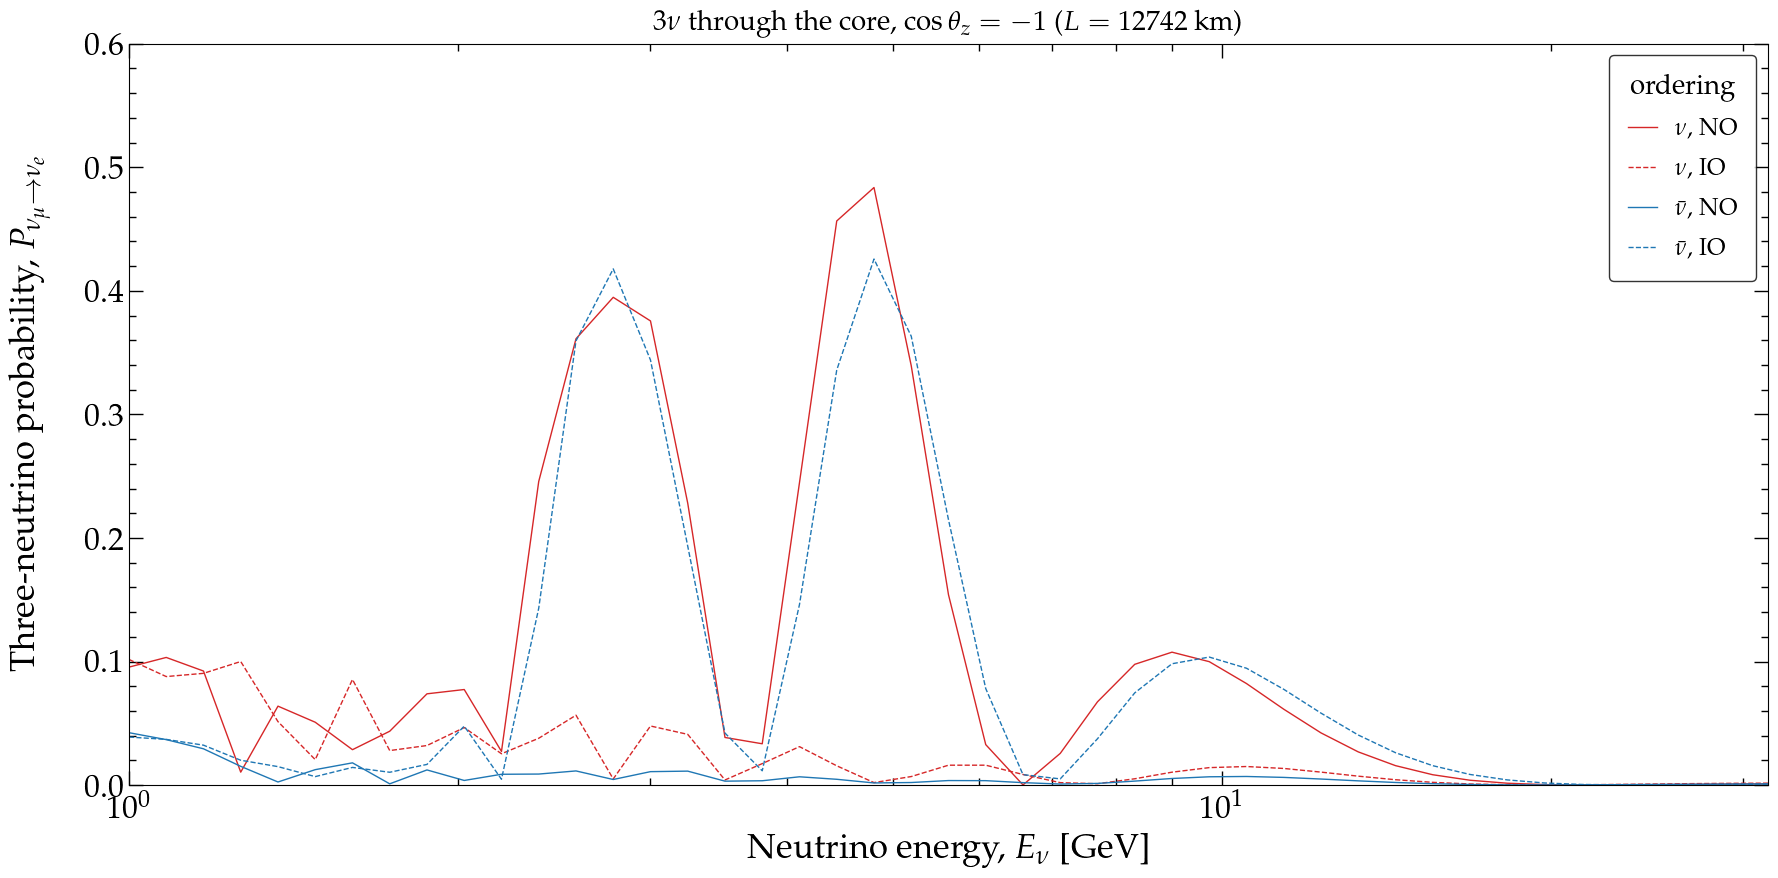

In [7]:
fig, ax = plotting.plot_probability_vs_energy(
    E_gev_earth,
    [dict(y=earth_p[('NO', False)], label=r'$\nu$, NO', color='C3'),
     dict(y=earth_p[('IO', False)], label=r'$\nu$, IO', color='C3', ls='--'),
     dict(y=earth_p[('NO', True)], label=r'$\bar\nu$, NO', color='C0'),
     dict(y=earth_p[('IO', True)], label=r'$\bar\nu$, IO', color='C0', ls='--')],
    nu_i=gd.NUMU, nu_f=gd.NUE, num_flavors=3,
    xlim=(E_gev_earth[0], E_gev_earth[-1]), ylim=(0.0, 0.6),
    legend_title='ordering', legend_loc='upper right',
    title=(r'$3\nu$ through the core, $\cos\theta_z = -1$ '
           r'($L = %.0f$ km)' % L_km))

## 4. The octant

Now hold the ordering fixed and move $\theta_{23}$ either side of maximal.
$\sin^2\theta_{23} = 0.45$ and $0.55$ give the *same* $\sin^2 2\theta_{23} = 0.99$, so the
leading term of the disappearance probability cannot distinguish them.

"Cannot distinguish" is often stated as an exact degeneracy. In three flavours it is not
exact -- subleading terms and the matter potential both break it -- but the residual is
small, which is the practical difficulty.

In [8]:
s2_lo, s2_hi = 0.45, 0.55
LO = dict(NO, s23=np.sqrt(s2_lo))
HI = dict(NO, s23=np.sqrt(s2_hi))
print('sin^2(2 th23): %.4f  and  %.4f  (identical to four decimals)'
      % (4*s2_lo*(1 - s2_lo), 4*s2_hi*(1 - s2_hi)))

for name, chan in (('mu -> mu  (disappearance)', dict(nu_i=gd.NUMU, nu_f=gd.NUMU)),
                   ('mu -> e   (appearance)   ', dict(nu_i=gd.NUMU, nu_f=gd.NUE))):
    v_lo = oscprob.osc_prob_3nu_vacuum(E, L, **LO, **chan)
    v_hi = oscprob.osc_prob_3nu_vacuum(E, L, **HI, **chan)
    m_lo = oscprob.osc_prob_3nu_matter_constant_density(
        E, L, RHO, **LO, density_matter_is_in_g_per_cm3=True, **chan)
    m_hi = oscprob.osc_prob_3nu_matter_constant_density(
        E, L, RHO, **HI, density_matter_is_in_g_per_cm3=True, **chan)
    print('%s  vacuum %.4f   matter %.4f'
          % (name, np.max(np.abs(v_lo - v_hi)), np.max(np.abs(m_lo - m_hi))))

sin^2(2 th23): 0.9900  and  0.9900  (identical to four decimals)
mu -> mu  (disappearance)  vacuum 0.0148   matter 0.0165


mu -> e   (appearance)     vacuum 0.0116   matter 0.0129


Both channels separate the octants by about one part in a hundred -- an order of
magnitude smaller than the ordering effect through the core, and comparable to the systematic
uncertainties of a real experiment. That is why the octant is still open while the ordering is
increasingly not.

## Summary

| question | carried by | where it shows | size |
|---|---|---|---|
| ordering | **sign of `D31`** | vacuum, 1300 km | 0.10 |
| | | crust, $\nu$ / $\bar\nu$ | 0.13 / 0.06 |
| | | **core chord, $\nu$ / $\bar\nu$** | **0.48 / 0.42** |
| octant | $\sin^2\theta_{23}$ vs $1-\sin^2\theta_{23}$ | 1300 km, either channel | ~0.015 |

Two practical notes. The shipped NuFIT NO and IO sets differ in ordering, octant *and*
$\delta_{\rm CP}$ simultaneously -- flip `D31` by hand if you want the ordering alone. And an
Earth chord needs its PREM shell boundaries passed as `t_breakpoints`: they are density jumps,
and a slab straddling one is not fixed by refinement.

---

**Previous:** [Exact versus the approximations](16_magnus_exact_vs_approximations.ipynb)  
**Next:** [Unusual density profiles](18_magnus_unusual_density_profiles.ipynb) --- arrangement beats the mean, except for one exact symmetry  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)